**What Flight Delay Patterns Reveal About Operational Pressure: An Exploratory Data Analysis**

# 1. Introduction

This analysis explores airline on-time performance using public Bureau of Transportation Statistics (BTS) Reporting Carrier On-Time Performance data from January 2023. The analysis treats delay patterns as operational signals rather than as evidence of responsibility by any single function. Findings should therefore be interpreted within this dataset context rather than as universal conclusions about all airline operations.

- Main report question:

    - **Which types of delays dominate airline operations, and what do they reveal about operational pressure?**

The objective of this analysis is to answer the following questions:

1. How are delay values distributed, and is disruption concentrated in a small number of flights?
2. Which delay causes account for the largest share of total delay?
3. Do delay patterns differ across operators?
4. What do these patterns reveal about operational pressure?


Time-of-day analysis is not included because the current dataset does not contain the required time fields. Operational pressure is therefore explored through delay distributions, delay-cause dominance, variation across operators, and propagation effects.

The following broad delay category definitions apply to this analysis:

- Carrier Delay: delay within the airline’s control, such as maintenance, crew, aircraft cleaning, baggage loading, or fuelling.
- Weather Delay: significant/extreme weather conditions affecting operation.
- NAS Delay: National Aviation System delays, including non-extreme weather, airport operations, heavy traffic, and air traffic control.
- Security Delay: security-related delay.
- Late Aircraft Delay: previous flight with the same aircraft arrived late, causing the current flight to depart late.

# 2. Data Loading and Overview

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_raw = pd.read_csv("T_ONTIME_REPORTING.csv")
df = df_raw.copy()

## 2.1. Data Inspection

In [275]:
df.head()

,YEAR,MONTH,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN,DEST,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2023,1,1/1/2023 12:00:00 AM,9E,ABE,ATL,1.0,-9.0,NaN,NaN,NaN,NaN,NaN
1,2023,1,1/1/2023 12:00:00 AM,9E,ABY,ATL,-12.0,0.0,NaN,NaN,NaN,NaN,NaN
2,2023,1,1/1/2023 12:00:00 AM,9E,ABY,ATL,-10.0,-11.0,NaN,NaN,NaN,NaN,NaN
3,2023,1,1/1/2023 12:00:00 AM,9E,AEX,ATL,91.0,72.0,11.0,0.0,0.0,0.0,61.0
4,2023,1,1/1/2023 12:00:00 AM,9E,AEX,ATL,425.0,427.0,0.0,83.0,2.0,0.0,342.0


In [276]:
df.shape

(538837, 13)

In [277]:
df.columns

Index(['YEAR', 'MONTH', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST',
       'DEP_DELAY', 'ARR_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
       'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY'],
      dtype='object')

In [278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538837 entries, 0 to 538836
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 538837 non-null  int64  
 1   MONTH                538837 non-null  int64  
 2   FL_DATE              538837 non-null  object 
 3   OP_UNIQUE_CARRIER    538837 non-null  object 
 4   ORIGIN               538837 non-null  object 
 5   DEST                 538837 non-null  object 
 6   DEP_DELAY            528855 non-null  float64
 7   ARR_DELAY            527197 non-null  float64
 8   CARRIER_DELAY        116713 non-null  float64
 9   WEATHER_DELAY        116713 non-null  float64
 10  NAS_DELAY            116713 non-null  float64
 11  SECURITY_DELAY       116713 non-null  float64
 12  LATE_AIRCRAFT_DELAY  116713 non-null  float64
dtypes: float64(7), int64(2), object(4)
memory usage: 53.4+ MB


The dataset contains 538,837 rows and 13 columns, including key delay variables and flight-level information.

In [279]:
# Numerical columns
display(df.select_dtypes(include='number').columns)

# Categorical columns
display(df.select_dtypes(include='object').columns)

Index(['YEAR', 'MONTH', 'DEP_DELAY', 'ARR_DELAY', 'CARRIER_DELAY',
       'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY'],
      dtype='object')

Index(['FL_DATE', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST'], dtype='object')

The next step is to inspect missing values in the dataset.

In [280]:
df.isna().sum()

YEAR                        0
MONTH                       0
FL_DATE                     0
OP_UNIQUE_CARRIER           0
ORIGIN                      0
DEST                        0
DEP_DELAY                9982
ARR_DELAY               11640
CARRIER_DELAY          422124
WEATHER_DELAY          422124
NAS_DELAY              422124
SECURITY_DELAY         422124
LATE_AIRCRAFT_DELAY    422124
dtype: int64

Several missing values are present in the delay-cause columns. In this analysis, missing delay-cause values are treated as no recorded delay minutes for that specific cause and are replaced with zero in the working dataset.

# 3. Data Cleaning

Missing values in the delay columns are replaced with zero in the working dataframe. This follows the assumption that missing delay-cause values represent no recorded delay minutes for that specific cause.

In [281]:
delay_cols = [
    "DEP_DELAY", "ARR_DELAY", "CARRIER_DELAY", "WEATHER_DELAY",
    "NAS_DELAY", "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

df[delay_cols] = df[delay_cols].fillna(0)

In [282]:
df[delay_cols].isna().sum()

DEP_DELAY              0
ARR_DELAY              0
CARRIER_DELAY          0
WEATHER_DELAY          0
NAS_DELAY              0
SECURITY_DELAY         0
LATE_AIRCRAFT_DELAY    0
dtype: int64

The check confirms that missing values in the selected delay columns have been replaced with zero.

The following columns will be kept for the purposes of this analysis:

Numerical:
 
- DEP_DELAY 
- ARR_DELAY 
- CARRIER_DELAY 
- WEATHER_DELAY 
- NAS_DELAY 
- SECURITY_DELAY 
- LATE_AIRCRAFT_DELAY 

Categorical:

- OP_UNIQUE_CARRIER

# 4. Exploratory Data Analysis (EDA)

## 4.1 Delay Distribution

### 4.1.1 Univariate Analysis

***1. How are delay values distributed, and is disruption concentrated in a small number of flights?***

This section covers summary statistics, mean/median comparison, skewness, coefficient of variation, distribution ranges, and histograms.

In [284]:
main_delay_cols = ["ARR_DELAY", "DEP_DELAY"]

cause_delay_cols = [
    "CARRIER_DELAY", "WEATHER_DELAY",
    "NAS_DELAY", "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

df_main_delays = df[main_delay_cols]
df_cause_delays = df[cause_delay_cols]

In [285]:
df_main_delays.describe()

,ARR_DELAY,DEP_DELAY
count,538837.000000,538837.000000
mean,7.608407,12.697584
std,56.784735,54.947767
min,-80.000000,-52.000000
25%,-15.000000,-6.000000
50%,-5.000000,-2.000000
75%,10.000000,9.000000
max,3063.000000,3024.000000


In [286]:
df_cause_delays.describe()

,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
count,538837.000000,538837.000000,538837.000000,538837.000000,538837.000000
mean,5.308765,0.949575,3.172887,0.031677,5.578737
std,35.769781,17.809380,16.298602,1.349076,28.790483
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000
max,3024.000000,1653.000000,1343.000000,234.000000,2027.000000


In [287]:
df_main_delays.median().sort_values()

ARR_DELAY   -5.0
DEP_DELAY   -2.0
dtype: float64

In [288]:
df_cause_delays.median().sort_values()

CARRIER_DELAY          0.0
WEATHER_DELAY          0.0
NAS_DELAY              0.0
SECURITY_DELAY         0.0
LATE_AIRCRAFT_DELAY    0.0
dtype: float64

In [289]:
main_delays_skew = df_main_delays.skew().sort_values(ascending = False)
main_delays_skew

DEP_DELAY    11.121737
ARR_DELAY     9.966315
dtype: float64

In [290]:
cause_delays_skew = df_cause_delays.skew().sort_values(ascending = False)
cause_delays_skew

SECURITY_DELAY         74.051320
WEATHER_DELAY          39.479667
CARRIER_DELAY          22.035317
NAS_DELAY              15.243767
LATE_AIRCRAFT_DELAY    14.100999
dtype: float64

In [294]:
coefficients_variation_main = df_main_delays.std()/df_main_delays.mean()

coefficients_variation_cause = df_cause_delays.std()/df_cause_delays.mean()

display(coefficients_variation_main)
display(coefficients_variation_cause)

ARR_DELAY    7.463420
DEP_DELAY    4.327419
dtype: float64

CARRIER_DELAY           6.737872
WEATHER_DELAY          18.755111
NAS_DELAY               5.136836
SECURITY_DELAY         42.587843
LATE_AIRCRAFT_DELAY     5.160753
dtype: float64

The coefficient of variation is used to compare variability relative to the mean across delay columns.

The histograms for main delays (Arrival and Departure) are zoomed to the 1st–99th percentile range to improve readability. Extreme values remain in the dataset and are reflected in the summary statistics.

Because arrival and departure delay can contain negative values that represent flights operating ahead of schedule, these columns are visualised without a logarithmic scale and with adjusted x-axis limits. Delay-cause columns are expected to be zero or positive, so a log-scaled y-axis can be used to improve readability where the distributions are highly skewed.

As such:

In [298]:
main_delay_label_map = {
    "ARR_DELAY": "Arrival",
    "DEP_DELAY": "Departure"
}

delay_label_map = {
    "CARRIER_DELAY": "Carrier",
    "WEATHER_DELAY": "Weather",
    "NAS_DELAY": "NAS",
    "SECURITY_DELAY": "Security",
    "LATE_AIRCRAFT_DELAY": "Late Aircraft"
}

delay_colour_map = {
    "Carrier": "#4C78A8",
    "Weather": "#F58518",
    "NAS": "#54A24B",
    "Security": "#B279A2",
    "Late Aircraft": "#E45756"
}

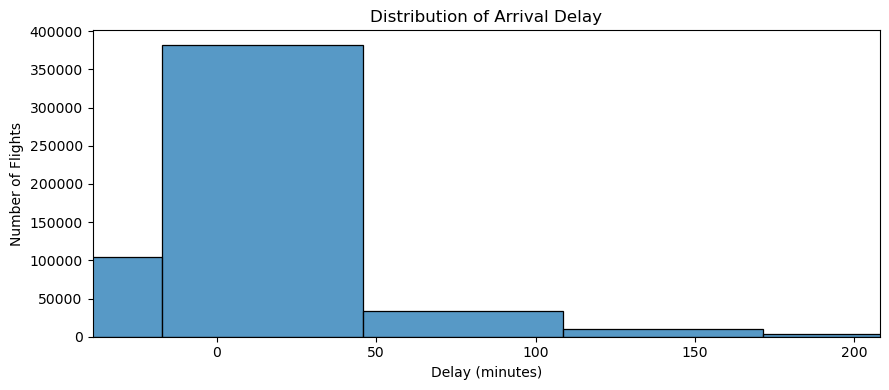

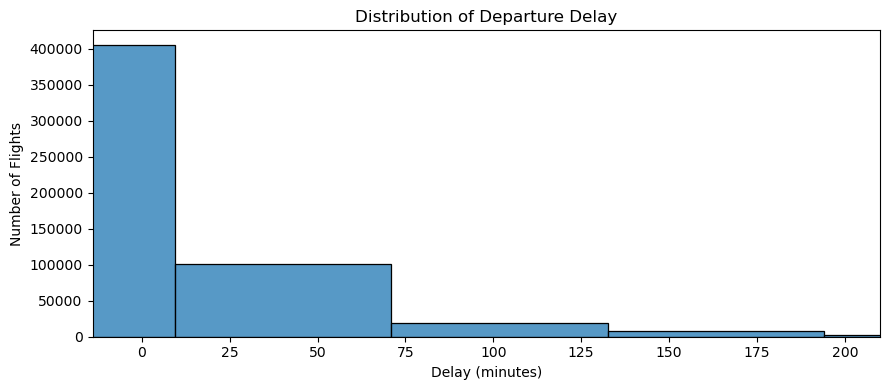

In [299]:
for col in df_main_delays.columns:
    label = main_delay_label_map[col]

    plt.figure(figsize=(9, 4))
    
    sns.histplot(
        data=df_main_delays,
        x=col,
        bins=50,
        kde=False
    )
    
    plt.title(f"Distribution of {label} Delay")
    plt.xlabel("Delay (minutes)")
    plt.ylabel("Number of Flights")
    plt.xlim(df_main_delays[col].quantile(0.01), df_main_delays[col].quantile(0.99))
    plt.tight_layout()
    plt.show()

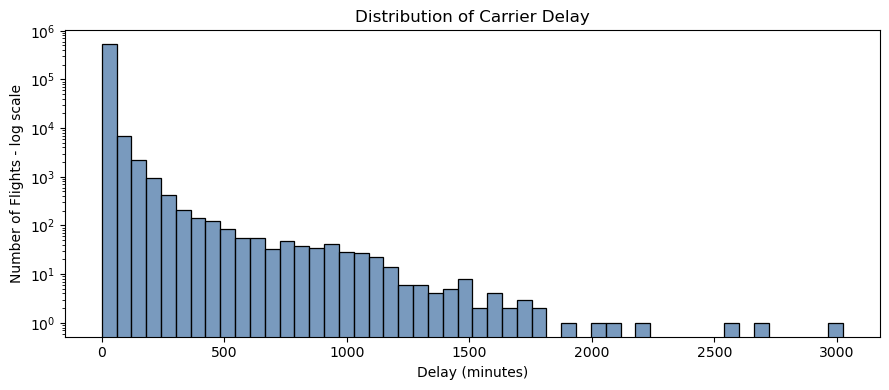

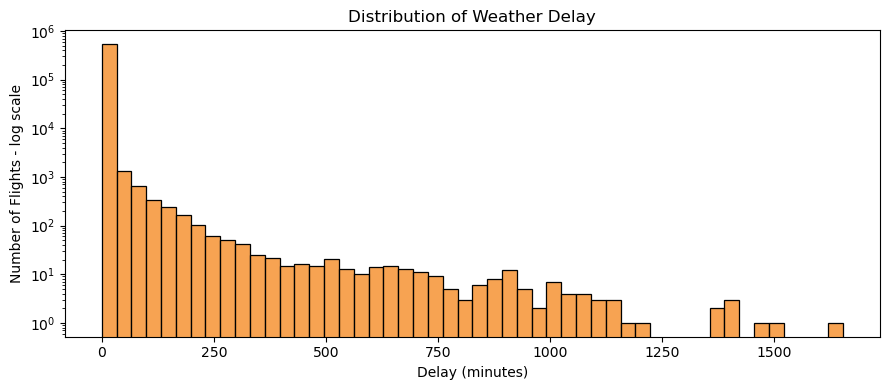

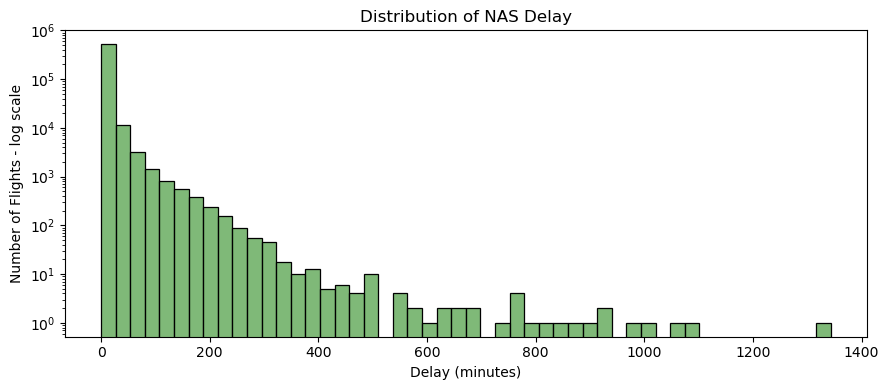

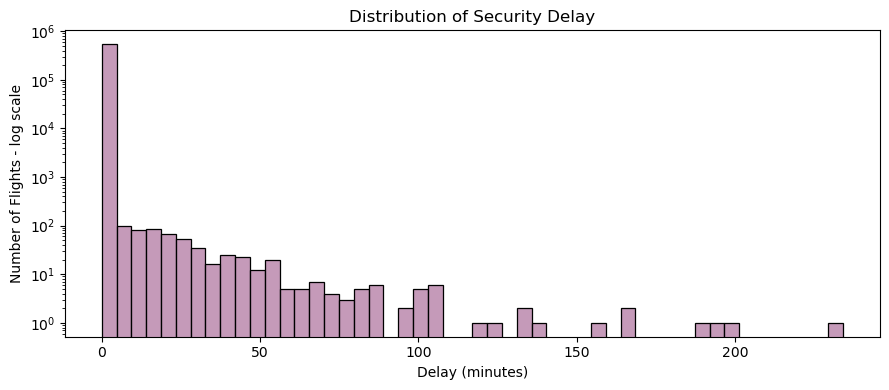

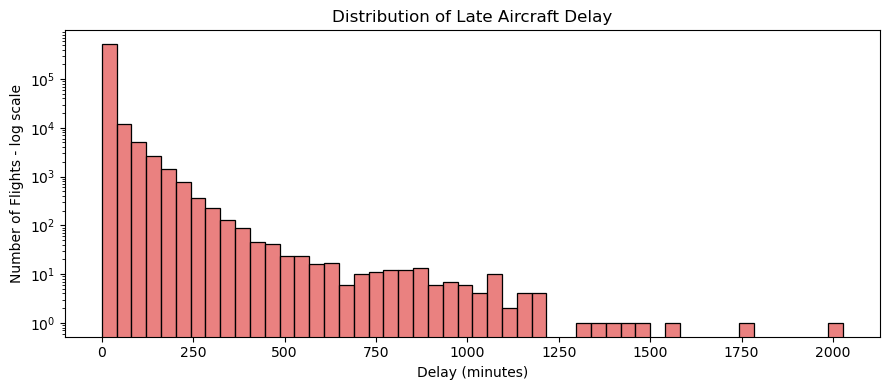

In [300]:
for col in df_cause_delays.columns:
    label = delay_label_map[col]
    
    plt.figure(figsize=(9, 4))
    sns.histplot(
        data=df_cause_delays,
        x=col,
        bins=50,
        color=delay_colour_map[label]
    )
    
    plt.yscale("log")
    plt.title(f"Distribution of {label} Delay")
    plt.xlabel("Delay (minutes)")
    plt.ylabel("Number of Flights - log scale")
    plt.tight_layout()
    plt.show()

Minimum and maximum values are checked to understand the full range of delay values, including early arrivals/departures and extreme delay cases. The plots are zoomed for readability, while the summary statistics preserve the full range of the data.

In [303]:
summary_arr_dep_delay = df_main_delays.agg(["min", "max"])
summary_arr_dep_delay = summary_arr_dep_delay.rename(index={"min": "Minimum", "max": "Maximum"})

summary_arr_dep_delay

,ARR_DELAY,DEP_DELAY
Minimum,-80.0,-52.0
Maximum,3063.0,3024.0


In [307]:
summary_cause_delay = df_cause_delays.agg(["min", "max"])
summary_cause_delay = summary_cause_delay.rename(index={"min": "Minimum", "max": "Maximum"})

summary_cause_delay

,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
Minimum,0.0,0.0,0.0,0.0,0.0
Maximum,3024.0,1653.0,1343.0,234.0,2027.0


### 4.1.2 Conclusions

Delay values are highly unevenly distributed. In January 2023, most flights recorded low or zero delay minutes, while a relatively small number of flights accounted for very large delay values. This is visible through zero or low medians, means that are higher than medians, strong positive skewness, and high maximum values.

The analysis therefore suggests that, in this dataset, disruption was concentrated in a minority of flights rather than spread evenly across the operation.

## 4.2 Delay Types Analysis

***2. Which delay causes account for the largest share of total delay?***

This section compares the numerical delay-cause columns. Arrival and departure delays are excluded here because they are overall outcomes, while the delay-cause columns describe how delay minutes are attributed across broad BTS categories.

In [311]:
# Calculating totals, renaming labels, and sorting values:

cause_totals = (
    df_cause_delays
    .sum()
    .rename(index=delay_label_map)
    .sort_values(ascending=False) / 60   # converting to hours
)

In [313]:
cause_totals_hours = cause_totals.round(2)
cause_totals_hours

Late Aircraft    50100.50
Carrier          47675.98
NAS              28494.48
Weather           8527.77
Security           284.48
dtype: float64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1732\3272624838.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


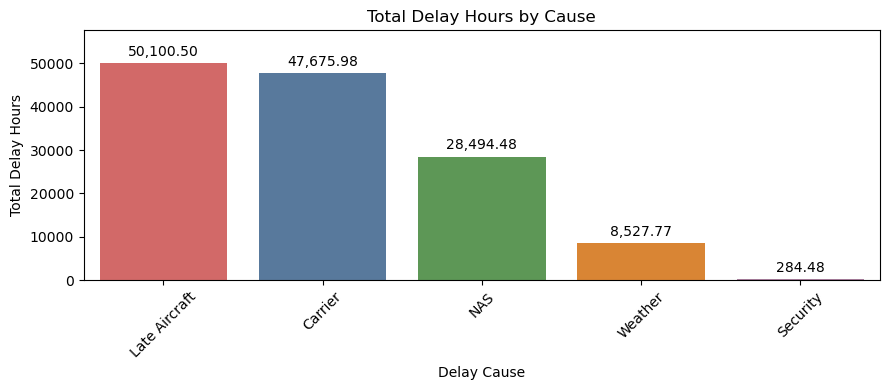

In [322]:
# Total delay hours by cause:
plt.figure(figsize=(9, 4))

ax = sns.barplot(
    x=cause_totals_hours.index,
    y=cause_totals_hours.values,
    palette=colours_ordered
)

for patch, value in zip(ax.patches, cause_totals_hours.values):
    height = patch.get_height()
    
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        height + cause_totals_hours.max() * 0.02,
        f"{value:,.2f}",
        ha="center",
        va="bottom"
    )

ax.set_ylim(0, cause_totals_hours.max() * 1.15)

plt.title("Total Delay Hours by Cause")
plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [314]:
# Creating colours in the same order as the sorted labels:

colours_ordered = [delay_colour_map[label] for label in cause_totals_hours.index]

In [315]:
cause_share = (cause_totals_hours / cause_totals_hours.sum() * 100).round(2)
cause_share

Late Aircraft    37.09
Carrier          35.29
NAS              21.09
Weather           6.31
Security          0.21
dtype: float64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1732\7578352.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


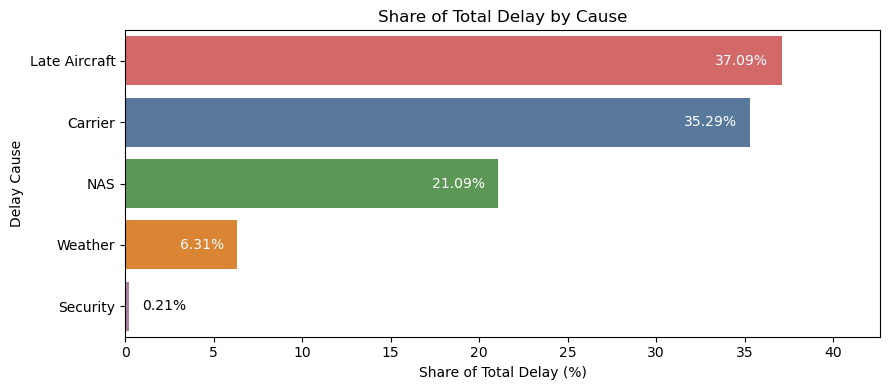

In [316]:
plt.figure(figsize=(9, 4))

ax = sns.barplot(
    x=cause_share.values,
    y=cause_share.index,
    palette=colours_ordered
)

for patch, value in zip(ax.patches, cause_share.values):
    width = patch.get_width()

    if width > cause_share.max() * 0.08:
        ax.text(
            width - cause_share.max() * 0.02,
            patch.get_y() + patch.get_height() / 2,
            f"{value:.2f}%",
            va="center",
            ha="right",
            color="white"
        )
    else:
        ax.text(
            width + cause_share.max() * 0.02,
            patch.get_y() + patch.get_height() / 2,
            f"{value:.2f}%",
            va="center",
            ha="left",
            color="black"
        )

ax.set_xlim(0, cause_share.max() * 1.15)

plt.title("Share of Total Delay by Cause")
plt.xlabel("Share of Total Delay (%)")
plt.ylabel("Delay Cause")
plt.tight_layout()
plt.show()

In [317]:
cause_summary = pd.DataFrame({
    "Total Delay Hours": cause_totals_hours,
    "Share of Total Delay (%)": cause_share
})

cause_summary

,Total Delay Hours,Share of Total Delay (%)
Late Aircraft,50100.50,37.09
Carrier,47675.98,35.29
NAS,28494.48,21.09
Weather,8527.77,6.31
Security,284.48,0.21


### 4.2.1 Conclusions

In the January 2023 dataset, Late Aircraft delay accounts for the largest share of total delay, followed by Carrier delay and NAS delay. This suggests that a significant portion of disruption is associated with propagation effects across aircraft rotations and broad operator-controlled categories, rather than being evenly distributed across all delay causes.

The remaining categories contribute comparatively less. Security delay contributed the smallest share in this dataset.

## 4.3 Operator-Level Delay Comparison

***3. Do delay patterns differ across operators?***

### 4.3.1 Bivariate Analysis

What follows is a categorical vs. numerical analysis of delay patterns across operators.

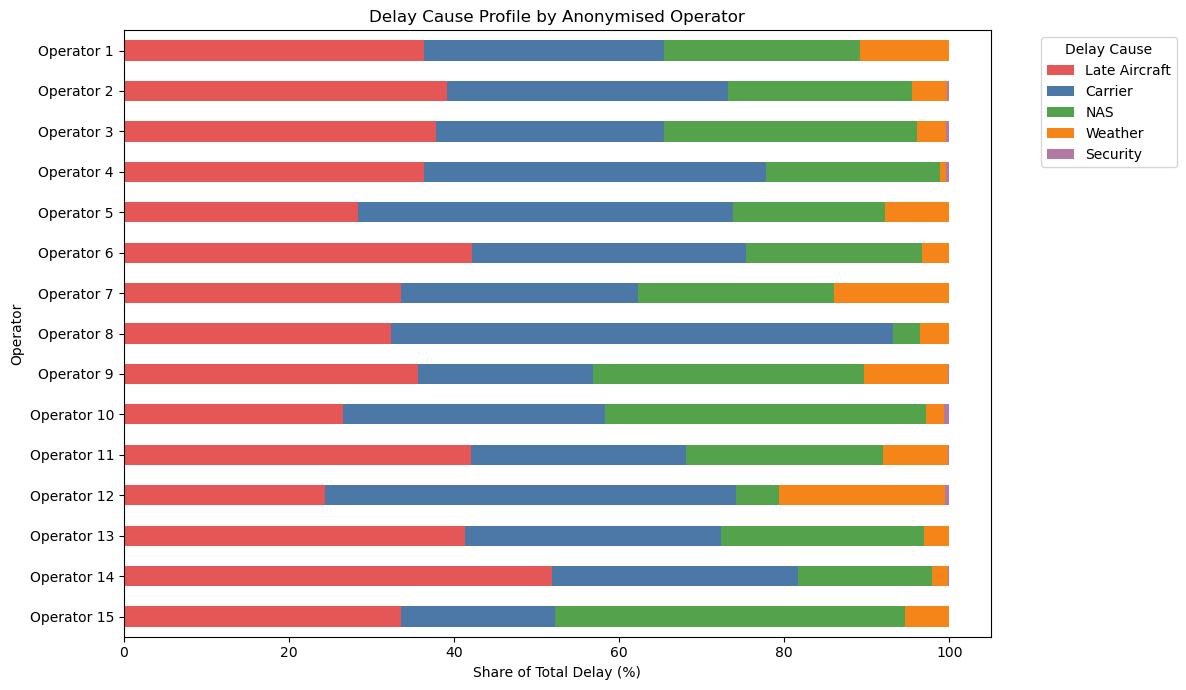

In [320]:
# Creating anonymised operator labels:
operator_codes = sorted(df["OP_UNIQUE_CARRIER"].unique())

anonymous_operator_map = {
    code: f"Operator {i+1}"
    for i, code in enumerate(operator_codes)
}

# Creating fixed operator order:
operator_order = [f"Operator {i+1}" for i in range(len(operator_codes))]

# Grouping delay causes by anonymised operator:
operator_delay_anon = (
    df.groupby(df["OP_UNIQUE_CARRIER"].map(anonymous_operator_map))[cause_delay_cols]
    .sum()
    .rename(columns=delay_label_map)
)

# Converting minutes to hours:
operator_delay_anon_hours = operator_delay_anon / 60

# Converting to percentage share per operator:
operator_delay_anon_share = operator_delay_anon_hours.div(
    operator_delay_anon_hours.sum(axis=1),
    axis=0
) * 100

# Sorting delay causes by overall importance:
cause_order = operator_delay_anon_hours.sum(axis=0).sort_values(ascending=False).index

# Applying fixed operator order and cause order:
operator_delay_anon_share_plot = (
    operator_delay_anon_share
    .reindex(operator_order)
    [cause_order]
)

# Using same fixed delay-cause colours:
colours = [delay_colour_map[col] for col in operator_delay_anon_share_plot.columns]

# Plot:
ax = operator_delay_anon_share_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7),
    color=colours
)

# Force Operator 1 at the top:
ax.invert_yaxis()

plt.xlabel("Share of Total Delay (%)")
plt.ylabel("Operator")
plt.title("Delay Cause Profile by Anonymised Operator")
plt.legend(title="Delay Cause", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [321]:
operator_delay_anon_share_table = (
    operator_delay_anon_share[cause_order]
    .reindex(operator_order)
    .round(2)
)

operator_delay_anon_share_table

,Late Aircraft,Carrier,NAS,Weather,Security
OP_UNIQUE_CARRIER,,,,,
Operator 1,36.35,29.11,23.69,10.82,0.03
Operator 2,39.12,34.01,22.28,4.31,0.27
Operator 3,37.85,27.61,30.60,3.59,0.35
Operator 4,36.42,41.38,21.01,0.76,0.43
Operator 5,28.33,45.42,18.47,7.72,0.06
Operator 6,42.14,33.25,21.31,3.30,0.00
Operator 7,33.62,28.61,23.79,13.88,0.11
Operator 8,32.39,60.82,3.17,3.53,0.08
Operator 9,35.59,21.26,32.79,10.23,0.13


### 4.3.2 Conclusions

The operator-level comparison shows that delay patterns differ across anonymised operators, with each operator displaying a distinct mix of delay causes. The stacked bar chart highlights these differences visually, while the percentage table provides the exact share of each delay cause by operator.

This suggests that delay behaviour is not uniform across the operation. Differences may reflect network structure, scheduling design, operational exposure, resource constraints, or exposure to external system pressures.

# 5. Key Findings

Within the January 2023 dataset analysed, three patterns stand out.

**Finding 1 - Delay values are highly unevenly distributed**

- Delay distributions are not evenly spread across all flights. Most flights record low or zero delay minutes, while a smaller number of flights account for much larger delay values. This pattern is visible through low or zero medians, means higher than medians, strong positive skewness, and high maximum values.

**Finding 2 - Total delay is concentrated in a small number of delay causes**

- Total delay is not evenly distributed across all delay categories. Late Aircraft delay is the largest contributor in this dataset, followed by Carrier delay and NAS delay. The remaining categories contribute comparatively less.


**Finding 3 - Delay-cause profiles differ across anonymised operators**

- Anonymised operators show different proportional mixes of delay causes. This suggests that delay behaviour is shaped by more than one universal factor and may reflect different network structures, scheduling patterns, operational exposure, and recovery dynamics.

# 6. Operational Interpretation

***4. What do these patterns reveal about operational pressure?***

These patterns suggest that operational pressure does not appear evenly across an airline operation. It tends to concentrate in specific flights, specific delay categories, and different operator profiles.

The highly skewed delay distributions show that a relatively small number of disrupted flights can carry a disproportionate share of total delay. From an operational perspective, this matters because average values alone can hide where disruption is actually concentrated.

The delay-cause analysis also suggests that delay should not be interpreted only as an isolated event. Some delay categories, especially those linked to aircraft arriving late from previous sectors, can reflect propagation effects across rotations. This should be interpreted as a system-level signal rather than evidence of responsibility by any single function.

The operator-level comparison reinforces this point. Different anonymised operators show different delay-cause profiles, which suggests that operational pressure may be shaped by network design, scheduling structure, resource availability, external system exposure, and recovery margins. A generic interpretation would therefore be too simplistic.

The value of this analysis is to show how public operational data can support better questions: where disruption concentrates, which delay categories dominate, and how different operating profiles may require different forms of attention.

# 7. Conclusion

This project used public BTS airline delay data from January 2023 to explore how operational pressure becomes visible through delay patterns. The analysis found that delay values are highly skewed, total delay is concentrated in a limited number of delay causes, and delay-cause profiles differ across anonymised operators.

These findings suggest that delay data can be useful beyond simple performance reporting. When interpreted carefully, it can help reveal where disruption concentrates, how it may propagate, and why different operating contexts may require different questions.

This analysis does not assign delay causes to maintenance, Tech Ops, or any single function. Instead, it demonstrates how exploratory data analysis can support clearer operational thinking in aviation.

## 7.1 Possible Next Steps

Future analysis could extend this work by exploring airport-level concentration, route-level patterns, or time-of-day effects if the required fields are included. These extensions could help answer questions such as where operational pressure concentrates across the network and how delays build throughout the operating day. These are possible future directions rather than conclusions from the current analysis.